# Multi Agents - 자율 연구 에이전트
LangGraph를 활용하여 동적 워크플로우, 루프/재귀, Human-in-the-loop 패턴을 구현하는 자율 연구 시스템을 만듭니다.

## 구성
1. **계획 에이전트**: 연구 주제 분석 및 계획 수립
2. **검색 에이전트**: 정보 수집 및 자료 검색
3. **분석 에이전트**: 수집된 데이터 분석
4. **검증 에이전트**: 정보의 신뢰성과 완성도 검증
5. **조정 에이전트**: 추가 조사 필요 여부 판단 및 워크플로우 제어
6. **보고서 에이전트**: 최종 연구 보고서 작성

## 학습 목표
- 동적 워크플로우 (Dynamic Workflow): 실행 중 경로 변경
- 루프와 재귀 (Loop & Recursion): 조건에 따라 반복 실행
- Human-in-the-loop (HITL): 중요한 결정에 사용자 개입


## 1. LLM


### API 키 설정
- [OpenAI API 키](https://platform.openai.com/api-keys)
- [Tavily API 키](https://tavily.com/) - 실제 웹 검색 기능 사용 (선택사항)

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
import os

# API 키 확인
openai_key = os.getenv("OPENAI_API_KEY")
tavily_key = os.getenv("TAVILY_API_KEY")

if openai_key:
    print("OpenAI API 키가 설정되었습니다. (GPT 모델 사용)")
else:
    print("OpenAI API 키가 없습니다.")

if tavily_key:
    print("Tavily API 키가 설정되었습니다. (웹 검색 사용)")
else:
    print("Tavily API 키가 없습니다. (검색 기능이 시뮬레이션 모드로 작동합니다)")

OpenAI API 키가 설정되었습니다. (GPT 모델 사용)
Tavily API 키가 설정되었습니다. (웹 검색 사용)


### LLM 초기화

In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

### Tavily 검색 도구 초기화 (실제 웹 검색용)

In [5]:
from langchain_tavily import TavilySearch

tavily_search = TavilySearch(
    max_results=3,
    topic="general",               # 또는 "news", "finance" 등
    include_answer=True,           # 답변 포함 여부
    include_raw_content=True,     # 원본 내용 포함 여부
    include_images=False,          # 이미지 포함 여부
    search_depth="advanced",          # "basic" 또는 "advanced"
    include_domains=[
        "https://www.naver.com", # 뉴스
        "https://www.weatheri.co.kr/", # 날씨 
        "https://kr.investing.com/equities/south-korea" # 주식
    ],
    exclude_domains=None            # 필요하면 제외 도메인 지정 가능
)

## 2. 상태 정의 (State Management)

고급 워크플로우를 위한 복잡한 상태 구조를 정의합니다. 루프 제어, 이력 관리, 검증 상태 등을 포함합니다.


In [6]:
from typing import TypedDict, List, Literal, Annotated
from operator import add

class ResearchState(TypedDict):
    """
    자율 연구 시스템의 상태를 정의하는 클래스
    """
    topic: str                                      # 연구 주제
    research_plan: str                              # 연구 계획
    search_results: Annotated[List[str], add]       # 검색 결과 리스트 (누적)
    analysis_results: Annotated[List[str], add]     # 분석 결과 리스트 (누적)
    verification_status: str                        # 검증 상태 (passed/failed)
    verification_feedback: str                      # 검증 피드백
    needs_more_research: bool                       # 추가 연구 필요 여부
    iteration_count: int                            # 반복 횟수 (무한 루프 방지)
    max_iterations: int                             # 최대 반복 횟수 (주제 복잡도에 따라 동적 설정)
    human_approval: bool                            # 사용자 승인 여부
    final_report: str                               # 최종 보고서

    

## 3. 에이전트 노드 정의


### 3.1 계획 에이전트


In [23]:
from langchain_core.messages import HumanMessage, SystemMessage

def __complexity_level_of_topic(state: ResearchState) -> dict:
    """
    주제의 복잡도를 평가하여 최대 반복 횟수를 동적으로 설정
    """
    topic = state["topic"]
    iteration = state.get("iteration_count", 0)
    max_iterations = state.get("max_iterations", 3)
    
    # 첫 번째 반복인 경우 주제 복잡도 평가
    if iteration == 0:
        complexity_messages = [
            SystemMessage(content="""
                당신은 연구 주제 복잡도 평가 전문가입니다.
                주어진 주제의 복잡도를 평가하세요:

                - SIMPLE: 단순하고 명확한 주제 (예: 특정 기술 소개, 단일 개념 설명)
                - MODERATE: 중간 복잡도 주제 (예: 기술 비교, 트렌드 분석)
                - COMPLEX: 복잡한 주제 (예: 다면적 분석, 미래 예측, 철학적 논의)

                반드시 "COMPLEXITY: SIMPLE", "COMPLEXITY: MODERATE", "COMPLEXITY: COMPLEX" 중 하나로 시작하세요."""),
            HumanMessage(content=f"주제: {topic}\n\n이 주제의 복잡도를 평가하세요.")
        ]
        
        complexity_response = llm.invoke(complexity_messages)
        complexity_text = complexity_response.content
        
        # 복잡도에 따른 최대 반복 횟수 설정
        if "COMPLEXITY: SIMPLE" in complexity_text:
            max_iterations = 2
            complexity_level = "단순"
        elif "COMPLEXITY: COMPLEX" in complexity_text:
            max_iterations = 4
            complexity_level = "복잡"
        else:
            max_iterations = 3
            complexity_level = "중간"
        
        print(f"[계획 에이전트] 주제 복잡도: {complexity_level} (최대 {max_iterations}회 반복)")
        
    return {
        "iteration": iteration,
        "max_iterations": max_iterations
    }

In [24]:
def __planning_of_topic(state: ResearchState):
    """
    연구 주제를 분석하고 상세한 연구 계획을 수립
    """
    topic = state["topic"]

    # 재연구인 경우 피드백 반영
    feedback = state.get("verification_feedback", "")
    feedback_context = f"\n\n이전 피드백: {feedback}" if feedback else ""
    
    messages = [
        SystemMessage(content="""
            당신은 연구 계획 전문가입니다.
            주어진 주제에 대해 체계적인 연구 계획을 수립하세요:
            1. 핵심 조사 질문 정의
            2. 필요한 정보 유형 파악
            3. 검색 키워드 제안
            4. 분석 방향 제시

            간결하고 실행 가능한 계획을 작성하세요."""),
        HumanMessage(content=f"주제: {topic}{feedback_context}\n\n연구 계획을 수립하세요.")
    ]
    
    response = llm.invoke(messages)
    
    return response.content

In [25]:
def planning_agent(state: ResearchState) -> dict:
    """
    연구 주제를 분석하고 상세한 연구 계획을 수립하는 에이전트
    주제의 복잡도를 평가하여 최대 반복 횟수를 동적으로 설정
    """
    complexity_level = __complexity_level_of_topic(state)
    iteration = complexity_level['iteration']
    max_iterations = complexity_level['max_iterations']
    
    plan = __planning_of_topic(state)
    
    print(f"[계획 에이전트] 연구 계획 수립 완료 (반복 {iteration + 1}회 / 최대 {max_iterations}회)")
    
    return {
        "research_plan": plan,
        "iteration_count": iteration + 1,
        "max_iterations": max_iterations
    }


### 3.2 검색 에이전트 (TavilySearchResults 사용)

실제 웹 검색을 수행하는 에이전트입니다. 

**TavilySearchResults 사용:**
- Tavily API 키가 있으면 실제 웹 검색 수행
- Tavily API 키가 없으면 시뮬레이션 모드로 작동
- API 키 발급: [Tavily](https://tavily.com/)

**참고:** Tavily API 키를 설정하려면 위의 API 키 설정 셀에서 주석을 제거하고 키를 입력하세요.


In [8]:
def search_agent(state: ResearchState) -> dict:
    """
    연구 계획에 따라 정보를 검색하고 수집하는 에이전트
    TavilySearchResults를 사용하여 실제 웹 검색 수행
    """
    topic = state["topic"]
    iteration = state['iteration_count']
    
    # Tavily 검색이 가능한 경우 실제 웹 검색 수행
    # 검색 쿼리 생성 (주제 + 계획의 핵심 키워드)
    search_query = f"{topic}"
    
    print(f"[검색 에이전트] 웹 검색 실행: {search_query}")
    
    # 실제 웹 검색 수행
    search_results_raw = tavily_search.invoke({"query": search_query})
    
    # 검색 결과를 포맷팅
    formatted_results = []
    for i, result in enumerate(search_results_raw['results'], 1):
        url = result.get('url', 'N/A')
        content = result.get('content', 'N/A')
        formatted_results.append(f"출처 {i}: {url}\n내용: {content}")
    
    search_result_text = "\n\n".join(formatted_results)
    
    # LLM을 사용하여 검색 결과 요약 및 분석
    summary_messages = [
        SystemMessage(content="""
        당신은 정보 분석 전문가입니다.
        웹 검색 결과를 분석하여 연구 주제와 관련된 핵심 정보를 요약하세요.
        - 각 출처의 주요 내용 정리
        - 관련성 높은 정보 강조
        - 상충되는 정보가 있다면 명시"""),
        HumanMessage(content=f"""
        주제: {topic}
        
        검색 결과:
        {search_result_text}
        
        이 결과를 요약하고 분석하세요.""")
    ]
    
    summary_response = llm.invoke(summary_messages)
    
    search_result = f"""
    [실제 웹 검색 결과 - 반복 {iteration}]
    
    {summary_response.content}
    
    --- 원본 검색 결과 ---
    {search_result_text[:500]}..."""
    
    print(f"[검색 에이전트] 실제 웹 검색 완료 ({len(search_results_raw)}개 결과)")
    
    return {
        "search_results": [search_result]
    }


### 3.3 분석 에이전트


In [9]:
def analysis_agent(state: ResearchState) -> dict:
    """
    수집된 정보를 분석하고 인사이트를 도출하는 에이전트
    """
    topic = state["topic"]
    search_results = state["search_results"]
    
    # 최신 검색 결과만 분석 (또는 전체 분석)
    recent_results = "\n\n".join(search_results[-3:])  # 최근 3개
    
    messages = [
        SystemMessage(content="""
            당신은 데이터 분석 전문가입니다.
            수집된 정보를 분석하여:
            1. 핵심 패턴과 트렌드 파악
            2. 주요 발견사항 정리
            3. 상충되는 정보 식별
            4. 추가 조사가 필요한 부분 지적

            분석적이고 비판적인 관점을 유지하세요."""),
        HumanMessage(content=f"주제: {topic}\n\n검색 결과:\n{recent_results}\n\n이 정보를 분석하세요.")
    ]
    
    response = llm.invoke(messages)
    analysis = f"[분석 결과 - 반복 {state['iteration_count']}]\n{response.content}"
    
    print(f"[분석 에이전트] 데이터 분석 완료")
    
    return {
        "analysis_results": [analysis]
    }


### 3.4 검증 에이전트


In [10]:
def verification_agent(state: ResearchState) -> dict:
    """
    정보의 신뢰성과 완성도를 검증하는 에이전트
    """
    topic = state["topic"]
    analysis_results = state["analysis_results"]
    
    # 최신 분석 결과 검토
    recent_analysis = "\n\n".join(analysis_results[-2:])
    
    messages = [
        SystemMessage(content="""
            당신은 연구 품질 검증 전문가입니다.
            분석 결과를 검토하고 다음을 판단하세요:
            1. 정보의 충분성 (충분한가?)
            2. 정보의 신뢰성 (출처가 믿을만한가?)
            3. 논리의 일관성 (모순이 없는가?)
            4. 추가 조사 필요 여부

            반드시 다음 형식으로 시작하세요:
            STATUS: PASSED 또는 STATUS: NEEDS_MORE_RESEARCH

            그 다음 상세한 피드백을 제공하세요."""),
        HumanMessage(content=f"주제: {topic}\n\n분석 결과:\n{recent_analysis}\n\n검증 결과를 제공하세요.")
    ]
    
    response = llm.invoke(messages)
    verification_result = response.content
    
    # 검증 상태 파싱
    if "STATUS: PASSED" in verification_result:
        status = "passed"
        needs_more = False
        print(f"[검증 에이전트] 검증 통과")
    else:
        status = "needs_more_research"
        needs_more = True
        print(f"[검증 에이전트] 추가 조사 필요")
    
    return {
        "verification_status": status,
        "verification_feedback": verification_result,
        "needs_more_research": needs_more
    }


### 3.5 조정 에이전트


In [11]:
def coordination_agent(state: ResearchState) -> dict:
    """
    워크플로우를 제어하고 다음 단계를 결정하는 에이전트
    동적으로 설정된 최대 반복 횟수를 사용
    """
    iteration = state["iteration_count"]
    needs_more = state["needs_more_research"]
    max_iterations = state.get("max_iterations", 3)  # 동적 최대 반복 횟수
    
    if needs_more and iteration < max_iterations:
        print(f"[조정 에이전트] 추가 조사 필요 - 검색으로 돌아갑니다 (반복 {iteration}/{max_iterations})")
        return {}
    elif iteration >= max_iterations:
        print(f"[조정 에이전트] 최대 반복 횟수 도달 ({max_iterations}회) - 현재 결과로 진행합니다")
        return {
            "needs_more_research": False,
            "verification_status": "max_iterations_reached"
        }
    else:
        print(f"[조정 에이전트] 연구 완료 - 보고서 작성 단계로 진행")
        return {}

#### Human-in-the-loop 노드

In [12]:
# Human-in-the-loop 노드
def human_review_node(state: ResearchState) -> dict:
    """
    사용자의 승인을 받는 노드 (Human-in-the-loop)
    """
    print("\n" + "="*80)
    print("[Human-in-the-loop] 사용자 검토 요청")
    print("="*80)
    print(f"현재 반복: {state['iteration_count']}/{state.get('max_iterations', 3)}")
    print(f"검증 상태: {state['verification_status']}")
    print(f"\n검증 피드백:\n{state['verification_feedback']}")
    print("="*80)
    
    # 실제 구현에서는 input()을 사용하지만, 
    # 자동 테스트를 위해 기본값 제공
    user_input = input("\n계속 진행하시겠습니까? (yes/no, 기본값: yes): ").strip().lower()
    
    if not user_input:
        user_input = "yes"
    
    approval = user_input in ["yes", "y", ""]
    
    if approval:
        print("[Human-in-the-loop] 승인됨 - 계속 진행")
    else:
        print("[Human-in-the-loop] 거부됨 - 워크플로우 중단")
    
    return {
        "human_approval": approval
    }


### 3.6 보고서 에이전트


In [16]:
def report_agent(state: ResearchState) -> dict:
    """
    모든 연구 결과를 종합하여 최종 보고서를 작성하는 에이전트
    """
    topic = state["topic"]
    plan = state["research_plan"]
    all_search = "\n\n".join(state["search_results"])
    all_analysis = "\n\n".join(state["analysis_results"])
    iterations = state["iteration_count"]
    
    messages = [
        SystemMessage(content="""
            당신은 연구 보고서 작성 전문가입니다.
            수집되고 분석된 모든 정보를 종합하여 체계적인 최종 보고서를 작성하세요:

            1. 요약 (Executive Summary)
            2. 연구 배경 및 목적
            3. 주요 발견사항
            4. 상세 분석
            5. 결론 및 제언
            6. 한계점 및 향후 연구 방향

            전문적이고 명확한 보고서를 작성하세요."""),
        HumanMessage(content=f"""
            주제: {topic}

            연구 계획:
            {plan}

            검색 결과:
            {all_search}

            분석 결과:
            {all_analysis}

            (총 {iterations}회 반복 조사 수행)

            위 내용을 바탕으로 최종 보고서를 작성하세요.""")
    ]
    
    response = llm.invoke(messages)
    report = response.content
    
    print(f"[보고서 에이전트] 최종 보고서 작성 완료")
    
    return {
        "final_report": report
    }


## 4. 동적 라우팅 함수

조건에 따라 다음 노드를 동적으로 결정하는 라우팅 함수들을 정의합니다.


In [17]:
def route_after_verification(state: ResearchState) -> Literal["human_review", "coordination"]:
    """
    검증 후 Human-in-the-loop 또는 조정으로 라우팅
    """
    max_iterations = state.get("max_iterations", 3)
    
    # 추가 연구가 필요하거나 최대 반복 도달 시 사람 검토
    needs_review = (
        state["needs_more_research"] or 
        state["iteration_count"] >= max_iterations
    )
    
    if needs_review:
        return "human_review"
    else:
        return "coordination"

In [18]:
def route_after_human_review(state: ResearchState) -> Literal["coordination", "report"]:
    """
    Human review 후 라우팅
    """
    if not state["human_approval"]:
        # 사용자가 거부한 경우 바로 보고서로 (중단)
        return "report"
    else:
        return "coordination"

In [19]:
def route_after_coordination(state: ResearchState) -> Literal["planning", "report"]:
    """
    조정 에이전트 후 루프 또는 종료 결정
    동적으로 설정된 최대 반복 횟수 사용
    """
    max_iterations = state.get("max_iterations", 3)
    
    # 추가 연구가 필요하고 최대 반복 미만이면 루프
    if state["needs_more_research"] and state["iteration_count"] < max_iterations:
        return "planning"  # 루프: 계획으로 돌아감
    else:
        return "report"  # 종료: 보고서 작성


## 5. 그래프 구성 (동적 워크플로우 + 루프)

복잡한 워크플로우를 구성합니다. 조건에 따라 경로가 변경되고, 필요시 루프를 돕니다.

### 그래프 구조
```
시작
  |
  v
계획 <----------+
  |             |
  v             |
검색            | (루프)
  |             |
  v             |
분석            |
  |             |
  v             |
검증            |
  |             |
  v             |
Human Review?   |
  |             |
  v             |
조정 -----------+
  |
  v
보고서
  |
  v
종료
```


In [26]:
from langgraph.graph import StateGraph, END

# StateGraph 생성
workflow = StateGraph(ResearchState)

# 노드 추가
workflow.add_node("planning", planning_agent)
workflow.add_node("search", search_agent)
workflow.add_node("analysis", analysis_agent)
workflow.add_node("verification", verification_agent)
workflow.add_node("human_review", human_review_node)
workflow.add_node("coordination", coordination_agent)
workflow.add_node("report", report_agent)

# 시작점 설정
workflow.set_entry_point("planning")

# 순차적 연결 (계획 -> 검색 -> 분석 -> 검증)
workflow.add_edge("planning", "search")
workflow.add_edge("search", "analysis")
workflow.add_edge("analysis", "verification")

# 검증 후 조건부 라우팅 (Human review 필요 여부)
workflow.add_conditional_edges(
    "verification",
    route_after_verification,
    {
        "human_review": "human_review",
        "coordination": "coordination"
    }
)

# Human review 후 라우팅
workflow.add_conditional_edges(
    "human_review",
    route_after_human_review,
    {
        "coordination": "coordination",
        "report": "report"
    }
)

# 조정 후 조건부 라우팅 (루프 또는 종료)
workflow.add_conditional_edges(
    "coordination",
    route_after_coordination,
    {
        "planning": "planning",  # 루프: 다시 계획으로
        "report": "report"       # 종료: 보고서로
    }
)

# 보고서에서 종료
workflow.add_edge("report", END)

# 그래프 컴파일
app = workflow.compile()



## 6. 그래프 시각화 (선택사항)


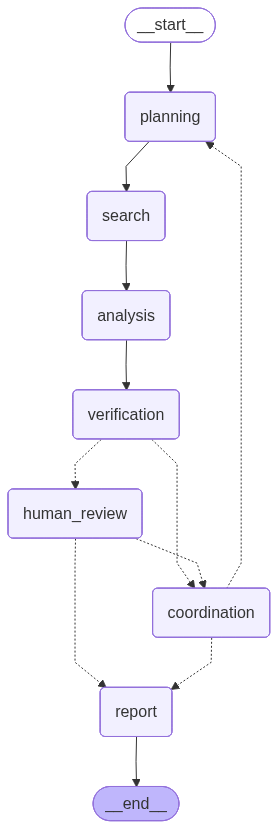

In [17]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            app.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")


## 7. 테스트 예제

자율 연구 시스템을 실행해봅니다.


### 7.1 연구 주제 설정


In [27]:
research_topic = "LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례"

print(f"연구 주제: {research_topic}")


연구 주제: LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례


### 7.2 자율 연구 실행

주의: Human-in-the-loop 단계에서 사용자 입력이 필요합니다.


In [28]:
print("=" * 80)
print("자율 연구 시스템 시작")
print("=" * 80)

# 초기 상태
initial_state = {
    "topic": research_topic,
    "research_plan": "",
    "search_results": [],
    "analysis_results": [],
    "verification_status": "",
    "verification_feedback": "",
    "needs_more_research": False,
    "iteration_count": 0,
    "max_iterations": 0,  
    "human_approval": True,
    "final_report": ""
}

# 그래프 실행
# 주의: input()이 호출되므로 실제 실행 시 사용자 입력 필요
result = app.invoke(initial_state)

print("\n" + "=" * 80)
print("연구 완료!")
print("=" * 80)


자율 연구 시스템 시작
[계획 에이전트] 주제 복잡도: 복잡 (최대 4회 반복)
[계획 에이전트] 연구 계획 수립 완료 (반복 1회 / 최대 4회)
[검색 에이전트] 웹 검색 실행: LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례
[검색 에이전트] 실제 웹 검색 완료 (7개 결과)
[분석 에이전트] 데이터 분석 완료
[검증 에이전트] 추가 조사 필요

[Human-in-the-loop] 사용자 검토 요청
현재 반복: 1/4
검증 상태: needs_more_research

검증 피드백:
STATUS: NEEDS_MORE_RESEARCH

상세 피드백

1) 종합 판단
- 분석은 LangGraph를 활용한 멀티에이전트 시스템의 장점, 패턴, 한계, 그리고 실무 활용을 위한 로드맵까지 포괄적으로 다루고 있어 실무 참고점으로 가치가 있습니다.
- 다만 LangGraph의 구체적 활용 근거가 제한적이며, 직접적인 사례·구현 세부가 충분히 확보되지 않은 상태입니다. 출처 간의 차이로 인해 일반화에 주의가 필요합니다.
- 따라서 현재 상태로는Implementation 결정이나 대규모 도입을 바로 뒷받침하기에는 부족하며, 추가 연구가 필요합니다.

2) 정보의 충분성 (충분한가?)
- 강점 요약과 실무 활용 로드맵, 성능·품질 관리 지표 제안 등은 높은 수준의 가이드를 제공합니다.
- 그러나 구체적이고 재현 가능한 근거가 부족합니다. 다음과 같은 요소가 보강되면 충분성 증가가 기대됩니다.
  - LangGraph의 공식 API/아키텍처 문서에서의 구체적 구현 세부
  - 실제 도입 사례의 수치 데이터(추론 속도, 메모리 사용량, 비용 등)와 정량적 ROI 분석
  - LangGraph를 직접 다룬 사례의 명확한 출처와 인용
- 제시된 추가 조사 항목은 적절하지만, 현재 결과물로서는 실행에 옮기기 위한 확실한 근거가 더 필요합니다.

3) 정보의 신뢰성 (출처가 믿을만한가?)
- 분석은 출처 1/2/3 등 여러 소스를 언급하나, 구체적인 출

### 7.3 최종 보고서 확인


In [29]:
print("\n" + "=" * 80)
print("최종 연구 보고서")
print("=" * 80)
print(f"\n총 반복 횟수: {result['iteration_count']}")
print(f"검증 상태: {result['verification_status']}")
print("\n" + "-" * 80)
print(result["final_report"])
print("-" * 80)



최종 연구 보고서

총 반복 횟수: 2
검증 상태: needs_more_research

--------------------------------------------------------------------------------
제목: LangGraph를 활용한 Multi-Agent 시스템(MAS)의 장단점과 실제 활용 사례에 관한 연구 보고서

1. Executive Summary (요약)
- 목적 및 맥락
  - 다중 에이전트 시스템에서 그래프 기반 추론의 도입이 협업 효율성, 의사결정 품질, 시스템 확장성에 미치는 구체적 효과를 평가하고, LangGraph의 아키텍처·설계 원칙을 정리하며, 실무 사례를 바탕으로 도입 로드맵을 제시합니다. 본 보고서는 주로 산업 현장의 블로그 글과 실무 가이드를 근거로 하며, LangGraph의 직접적 실증 자료는 제한적임을 명시합니다. (출처: 출처 1, 출처 2, 출처 3)
- 핵심 발견
  - 장점 요약: LangGraph는 에이전트 간 흐름의 시각화/추적성을 강화하고 모듈화된 설계를 촉진하며, GraphRAG/AgentRAG 같은 기법과의 결합으로 품질 관리 및 자기 교정 가능성을 높일 수 있습니다. 운영 측면에서도 Kubernetes 기반 CI/CD 같은 자동화와 관찰성 강화와의 연계가 가능하다는 점이 반복적으로 시사됩니다. (출처 2)
  - 실무 사례의 맥락: 기관 내 LangChain/LangGraph 중심의 서비스 고도화 사례와 로그 기반 탐지/보안 영역의 실무 맥락이 제시되며, LangGraph의 도입으로 서비스 흐름의 추적성과 모듈화가 강화될 수 있다는 시각이 공유됩니다. 다만 LangGraph의 직접적 구체 사례는 제한적이고, 대부분 도메인 맥락에서의 설계 원칙과 구현 전략이 주로 다뤄집니다. (출처 1, 출처 2, 출처 3)
- 실무 활용 로드맷 제안
  - 파일럿→MVP→확대의 단계별 설계 원칙, KPI 설정, 리스크 관리, 보안/프라이버시 고려사항과 운영 비용 관리가 권고됩니다. 또한 MV

### 7.4 연구 과정 추적


In [30]:
print("\n" + "=" * 80)
print("연구 과정 추적")
print("=" * 80)

print(f"\n[검색 결과 수집]: {len(result['search_results'])}회")
for i, search in enumerate(result['search_results'], 1):
    print(f"\n--- 검색 {i} ---")
    print(search[:200] + "..." if len(search) > 200 else search)

print(f"\n\n[분석 수행]: {len(result['analysis_results'])}회")
for i, analysis in enumerate(result['analysis_results'], 1):
    print(f"\n--- 분석 {i} ---")
    print(analysis[:200] + "..." if len(analysis) > 200 else analysis)



연구 과정 추적

[검색 결과 수집]: 2회

--- 검색 1 ---

    [실제 웹 검색 결과 - 반복 1]

    다음은 제시된 검색 결과를 바탕으로, LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례를 정리한 분석 요약입니다.

1) 출처별 주요 내용 요약

- 출처 1 (블로그, 위협 탐지 사례)
  - 주요 내용: 실제로 적용된 사례로, 로그 패턴 분석 기반 위협 탐지 시스템이 ...

--- 검색 2 ---

    [실제 웹 검색 결과 - 반복 2]

    다음은 주제인 “LangGraph를 활용한 Multi-Agent 시스템(MAS)의 장단점과 실제 활용 사례”에 대해 주어진 검색 결과를 요약하고 분석한 내용입니다.

1) 출처별 요약

- 출처 1 (https://blog.naver.com/n_cloudplatform/223938853841)
  - 핵...


[분석 수행]: 2회

--- 분석 1 ---
[분석 결과 - 반복 1]
다음은 제시된 검색 결과를 바탕으로 한 LangGraph를 활용한 Multi-Agent 시스템 분석입니다. 핵심 패턴, 주요 발견, 상충 정보 여부, 그리고 추가 조사 필요 영역을 정리했습니다.

1) 분석의 요지 요약
- LangGraph의 주된 가치는 에이전트 간 흐름의 추적성과 모듈화에 있으며, 품질 관리(Hybrid Sea...

--- 분석 2 ---
[분석 결과 - 반복 2]
다음은 주어진 검색 결과를 토대로, LangGraph를 활용한 Multi-Agent 시스템(MAS)의 장단점과 실제 활용 사례를 분석한 정리입니다.

1) 핵심 패턴과 트렌드 파악
- 모듈화와 연결성의 강화
  - LangChain/LangGraph/AutoGen 등 여러 에이전트 프레임워크를 조합해 에이전트를 모듈화하고, 서로 ...
